In [69]:
import os
import warnings

import agama
import astropy
import gc_utils
import gizmo_analysis as gizmo
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import utilities as ut
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from sklearn.svm import SVC

In [95]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"
snap = 600

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

In [136]:
it_dict = {}
for it_id in ghost_data.keys():
    src_dat = ghost_data[it_id]["source"]
    gcids_src = src_dat["gcid"][()]
    torbs_600 = src_dat["torb_600"][()]
    birth_r = src_dat["halo.r.birth"][()]
    m_tfor = 10 ** src_dat["logm_tfor"][()]

    grpids_src = np.abs(src_dat["grpid"][()])
    grpids_unq = np.unique(grpids_src)

    snap_id = gc_utils.snapshot_name(snap)
    snp_dat = ghost_data[it_id]["snapshots"][snap_id]

    grpids_snp = np.abs(snp_dat["grpid"][()])

    grp_dict = {grpid: {"cnt": np.nan, "mwpz0": np.nan, "mwbr": np.nan} for grpid in grpids_unq}

    for grpid in grp_dict.keys():
        grpid_snp_msk = grpids_snp == grpid
        grp_dict[grpid]["cnt"] = np.sum(grpid_snp_msk)

        grpid_src_msk = grpids_src == grpid
        grp_dict[grpid]["mwpz0"] = np.average(torbs_600[grpid_src_msk], weights=m_tfor[grpid_src_msk])
        grp_dict[grpid]["mwbr"] = np.average(birth_r[grpid_src_msk], weights=m_tfor[grpid_src_msk])
        grp_dict[grpid]["tmass"] = np.sum(m_tfor[grpid_src_msk])
        grp_dict[grpid]["avgmass"] = np.average(m_tfor[grpid_src_msk])

    it_dict[it_id] = grp_dict

Text(0, 0.5, 'Clusters Remaining at z=0')

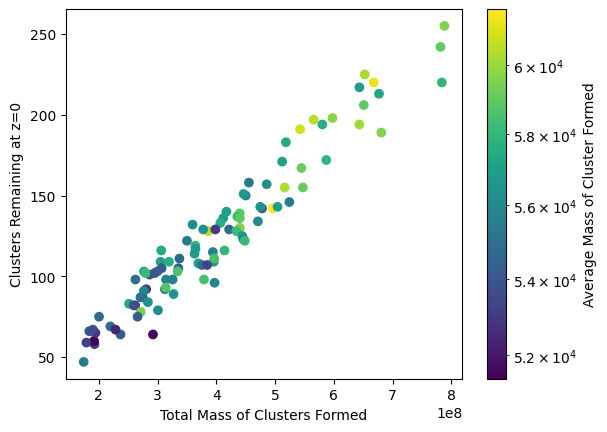

In [144]:
# grpid = 8580896
grpid = 0

# x = [it_dict[it_id][grpid]["mwpz0"] for it_id in it_dict.keys()]
x = [it_dict[it_id][grpid]["tmass"] for it_id in it_dict.keys()]
y = [it_dict[it_id][grpid]["cnt"] for it_id in it_dict.keys()]
c = [it_dict[it_id][grpid]["avgmass"] for it_id in it_dict.keys()]

plt.scatter(x, y, c=c, norm=LogNorm())
plt.colorbar(label="Average Mass of Cluster Formed")
# plt.xscale("log")
# plt.yscale("log")

plt.xlabel("Total Mass of Clusters Formed")
plt.ylabel("Clusters Remaining at z=0")

# if you produce more clusters you are more likely to produce higher mass clusters (via schecter
# function sampling) and so you will have more clusters remaining at z=0